## Network Intrusion Detection Using XGBoost

In this project, we built a machine learning model to classify network traffic and detect potential cyber-attacks. Using the XGBoost algorithm, we trained the model on labeled network data, fine-tuned it with GridSearchCV, and evaluated its performance with key metrics like F1-score, Recall, and ROC AUC. The goal was to create a reliable and efficient intrusion detection system that can help strengthen network security.



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

pd.set_option('display.float_format', lambda x: '%.3f' % x)
plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
df_0 = pd.read_csv(r"C:\Users\Prathap\Desktop\Infosys Project\SentinelNet\Dataset\nsl-kdd\KDDTrain+.txt")
df = df_0.copy()

df.head()

,0,tcp,ftp_data,SF,491,0.1,0.2,0.3,0.4,0.5,...,0.17,0.03,0.17.1,0.00.6,0.00.7,0.00.8,0.05,0.00.9,normal,20
0,0,udp,other,SF,146,0,0,0,0,0,...,0.000,0.600,0.880,0.000,0.000,0.000,0.000,0.000,normal,15
1,0,tcp,private,S0,0,0,0,0,0,0,...,0.100,0.050,0.000,0.000,1.000,1.000,0.000,0.000,neptune,19
2,0,tcp,http,SF,232,8153,0,0,0,0,...,1.000,0.000,0.030,0.040,0.030,0.010,0.000,0.010,normal,21
3,0,tcp,http,SF,199,420,0,0,0,0,...,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,normal,21
4,0,tcp,private,REJ,0,0,0,0,0,0,...,0.070,0.070,0.000,0.000,0.000,0.000,1.000,1.000,neptune,21


In [3]:
columns = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins',
    'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root',
    'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds',
    'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate',
    'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
    'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
    'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate',
    'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
    'dst_host_srv_rerror_rate', 'attack', 'level'
]

# Assign the column names to the dataframe
df.columns = columns

In [4]:
df.head(5)

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack,level
0,0,udp,other,SF,146,0,0,0,0,0,...,0.000,0.600,0.880,0.000,0.000,0.000,0.000,0.000,normal,15
1,0,tcp,private,S0,0,0,0,0,0,0,...,0.100,0.050,0.000,0.000,1.000,1.000,0.000,0.000,neptune,19
2,0,tcp,http,SF,232,8153,0,0,0,0,...,1.000,0.000,0.030,0.040,0.030,0.010,0.000,0.010,normal,21
3,0,tcp,http,SF,199,420,0,0,0,0,...,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,normal,21
4,0,tcp,private,REJ,0,0,0,0,0,0,...,0.070,0.070,0.000,0.000,0.000,0.000,1.000,1.000,neptune,21


In [5]:
# basic information 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125972 entries, 0 to 125971
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125972 non-null  int64  
 1   protocol_type                125972 non-null  object 
 2   service                      125972 non-null  object 
 3   flag                         125972 non-null  object 
 4   src_bytes                    125972 non-null  int64  
 5   dst_bytes                    125972 non-null  int64  
 6   land                         125972 non-null  int64  
 7   wrong_fragment               125972 non-null  int64  
 8   urgent                       125972 non-null  int64  
 9   hot                          125972 non-null  int64  
 10  num_failed_logins            125972 non-null  int64  
 11  logged_in                    125972 non-null  int64  
 12  num_compromised              125972 non-null  int64  
 13 

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
duration,125972.000,287.147,2604.526,0.000,0.000,0.000,0.000,42908.000
src_bytes,125972.000,45567.101,5870354.481,0.000,0.000,44.000,276.000,1379963888.000
dst_bytes,125972.000,19779.271,4021285.112,0.000,0.000,0.000,516.000,1309937401.000
land,125972.000,0.000,0.014,0.000,0.000,0.000,0.000,1.000
wrong_fragment,125972.000,0.023,0.254,0.000,0.000,0.000,0.000,3.000
urgent,125972.000,0.000,0.014,0.000,0.000,0.000,0.000,3.000
hot,125972.000,0.204,2.150,0.000,0.000,0.000,0.000,77.000
num_failed_logins,125972.000,0.001,0.045,0.000,0.000,0.000,0.000,5.000
logged_in,125972.000,0.396,0.489,0.000,0.000,0.000,1.000,1.000
num_compromised,125972.000,0.279,23.942,0.000,0.000,0.000,0.000,7479.000


## Data Cleaning

In [7]:
df.isnull().sum()

duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_root                       0
num_file_creations             0
num_shells                     0
num_access_files               0
num_outbound_cmds              0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_rate                  0
diff_srv_rate                  0
srv_diff_h

In [8]:
def unique_values(df, columns):
    """
    Prints unique values and their counts for each specified column in the DataFrame.
    
    Parameters:
    df (DataFrame): The input DataFrame to analyze.
    columns (list): A list of column names to inspect.
    """
    for column_name in columns:
        print(f"Column: {column_name}\n{'-'*30}")
        unique_vals = df[column_name].unique()
        value_counts = df[column_name].value_counts()
        
        print(f"Unique Values ({len(unique_vals)}): {unique_vals}\n")
        print(f"Value Counts:\n{value_counts}\n{'='*40}\n")

In [9]:
cat_features = df.select_dtypes(include='object').columns

unique_values(df, cat_features)

Column: protocol_type
------------------------------
Unique Values (3): ['udp' 'tcp' 'icmp']

Value Counts:
protocol_type
tcp     102688
udp      14993
icmp      8291
Name: count, dtype: int64

Column: service
------------------------------
Unique Values (70): ['other' 'private' 'http' 'remote_job' 'ftp_data' 'name' 'netbios_ns'
 'eco_i' 'mtp' 'telnet' 'finger' 'domain_u' 'supdup' 'uucp_path' 'Z39_50'
 'smtp' 'csnet_ns' 'uucp' 'netbios_dgm' 'urp_i' 'auth' 'domain' 'ftp'
 'bgp' 'ldap' 'ecr_i' 'gopher' 'vmnet' 'systat' 'http_443' 'efs' 'whois'
 'imap4' 'iso_tsap' 'echo' 'klogin' 'link' 'sunrpc' 'login' 'kshell'
 'sql_net' 'time' 'hostnames' 'exec' 'ntp_u' 'discard' 'nntp' 'courier'
 'ctf' 'ssh' 'daytime' 'shell' 'netstat' 'pop_3' 'nnsp' 'IRC' 'pop_2'
 'printer' 'tim_i' 'pm_dump' 'red_i' 'netbios_ssn' 'rje' 'X11' 'urh_i'
 'http_8001' 'aol' 'http_2784' 'tftp_u' 'harvest']

Value Counts:
service
http         40338
private      21853
domain_u      9043
smtp          7313
ftp_data      6859
 

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.shape

(125972, 43)

In [12]:
# Convert the attack column to binary labels: 'normal' or 'attack'
df['attack'] = df['attack'].apply(lambda x: 'normal' if x == 'normal' else 'attack')

In [13]:
df['attack'].unique()

array(['normal', 'attack'], dtype=object)

In [14]:
# Identify all categorical columns in the dataset
cat_features = df.select_dtypes(include='object').columns

# Display the list of categorical features
cat_features

Index(['protocol_type', 'service', 'flag', 'attack'], dtype='object')

In [15]:
from sklearn import preprocessing
le=preprocessing.LabelEncoder()
clm=['protocol_type', 'service', 'flag', 'attack']
for x in clm:
    df[x]=le.fit_transform(df[x])

In [16]:
from sklearn.model_selection import train_test_split

X = df.drop(["attack"], axis=1)
y = df["attack"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.1,     
    random_state=43     # Ensures reproducibility
)

In [17]:
train_index = X_train.columns
train_index

Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
       'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
       'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'level'],
      dtype='object')

In [18]:
from sklearn.feature_selection import mutual_info_classif

mutual_info = mutual_info_classif(X_train, y_train)

mutual_info = pd.Series(mutual_info)

mutual_info.index = train_index  # NOTE: 'train_index' must be a list of feature names

mutual_info.sort_values(ascending=False)

src_bytes                     0.566
service                       0.470
dst_bytes                     0.442
flag                          0.368
same_srv_rate                 0.366
diff_srv_rate                 0.361
dst_host_srv_count            0.336
dst_host_same_srv_rate        0.312
logged_in                     0.292
dst_host_serror_rate          0.287
dst_host_diff_srv_rate        0.284
dst_host_srv_serror_rate      0.283
serror_rate                   0.278
srv_serror_rate               0.267
count                         0.266
dst_host_srv_diff_host_rate   0.189
level                         0.152
dst_host_count                0.144
dst_host_same_src_port_rate   0.131
srv_diff_host_rate            0.099
srv_count                     0.066
dst_host_srv_rerror_rate      0.062
protocol_type                 0.052
rerror_rate                   0.043
srv_rerror_rate               0.038
dst_host_rerror_rate          0.037
duration                      0.025
wrong_fragment              

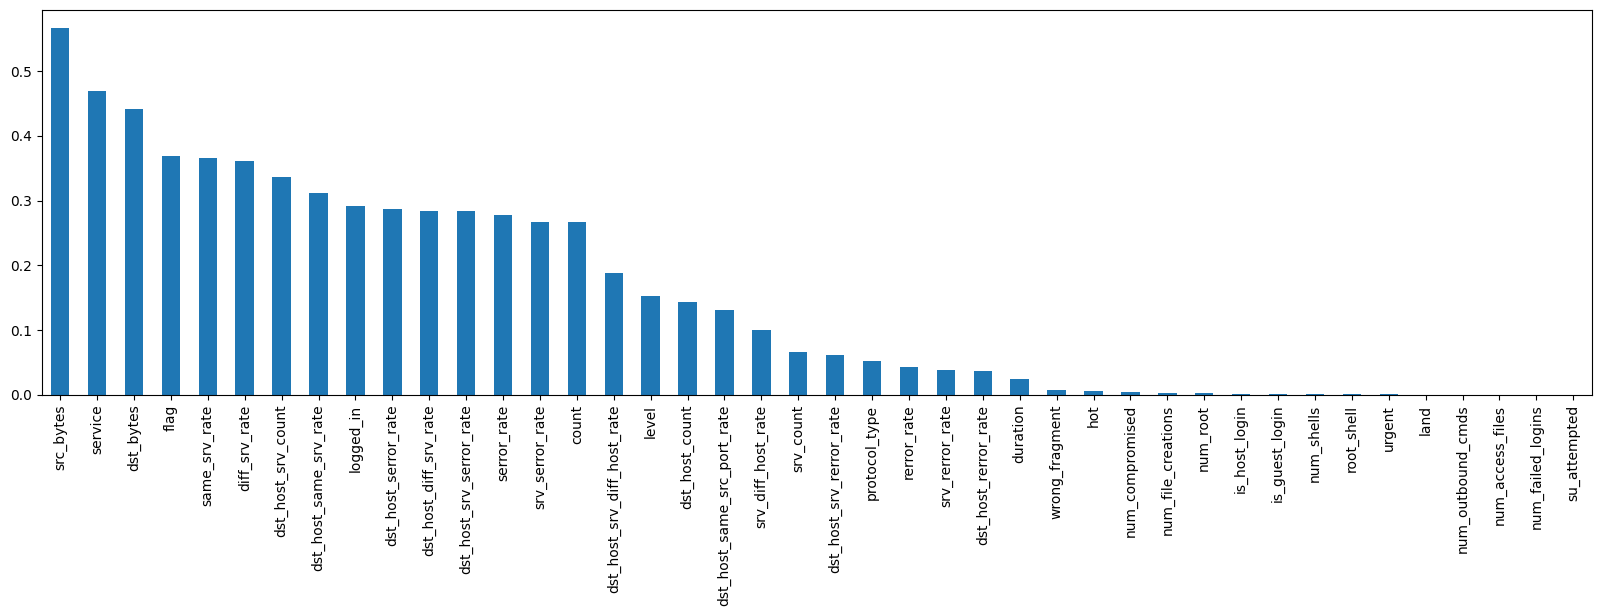

In [19]:
mutual_info.sort_values(ascending=False).plot.bar(figsize=(20, 5));

In [20]:
from sklearn.feature_selection import SelectKBest

Select_features = SelectKBest(mutual_info_classif, k=30)

Select_features.fit(X_train, y_train)

# Display the names of the selected top 30 features
train_index[Select_features.get_support()]

Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'wrong_fragment', 'hot', 'logged_in', 'num_compromised',
       'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate',
       'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate',
       'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
       'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
       'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate',
       'dst_host_serror_rate', 'dst_host_srv_serror_rate',
       'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'level'],
      dtype='object')

In [21]:
columns = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes',
    'dst_bytes', 'wrong_fragment', 'hot', 'logged_in', 'num_compromised',
    'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate'
]

X_train = X_train[columns]
X_test = X_test[columns]

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [23]:
from xgboost import XGBClassifier                         

In [24]:
XGBoost_model = XGBClassifier(random_state=42)


In [25]:
# Train the XGBoost model using the training set
XGBoost = XGBoost_model.fit(X_train, y_train)

In [26]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    roc_auc_score
)

In [27]:
def eval_metric(model, X_train, y_train, X_test, y_test):
    # Predict on training and test sets
    y_train_pred = model.predict(X_train)
    y_pred = model.predict(X_test)
    
    # Evaluation on test set
    print("Test Set")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print()
    
    # Evaluation on training set
    print("Train Set")
    print(confusion_matrix(y_train, y_train_pred))
    print(classification_report(y_train, y_train_pred))

In [28]:
eval_metric(XGBoost_model, X_train, y_train, X_test, y_test)

Test Set
[[5816   12]
 [   8 6762]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5828
           1       1.00      1.00      1.00      6770

    accuracy                           1.00     12598
   macro avg       1.00      1.00      1.00     12598
weighted avg       1.00      1.00      1.00     12598


Train Set
[[52746    56]
 [   29 60543]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     52802
           1       1.00      1.00      1.00     60572

    accuracy                           1.00    113374
   macro avg       1.00      1.00      1.00    113374
weighted avg       1.00      1.00      1.00    113374



## Hyperparameter Tuning

In [29]:
# Define the grid of hyperparameters for XGBoost tuning
param_grid = {
    "n_estimators": [50, 64, 100, 128],           # Number of trees
    "max_depth": [2, 3, 4, 5, 6],                 # Maximum depth of each tree
    "learning_rate": [0.01, 0, 0.03, 0.05, 0.1],  # Step size shrinkage
    "subsample": [0.5, 0.8],                      # Fraction of training data used per tree
    "colsample_bytree": [0.5, 0.8]                # Fraction of features used per tree
}

In [30]:
from sklearn.model_selection import GridSearchCV

# Initialize the base XGBoost model
XGB_model = XGBClassifier(random_state=42)

# Define the hyperparameter grid to search
param_grid = {
    "n_estimators": [50, 64, 100, 128],        # Number of boosting rounds
    "max_depth": [2, 3, 4, 5, 6],              # Maximum depth of each tree
    "learning_rate": [0.01, 0, 0.03, 0.05, 0.1], # Step size shrinkage
    "subsample": [0.5, 0.8],                   # Fraction of samples used per tree
    "colsample_bytree": [0.5, 0.8]             # Fraction of features used per tree
}

# Perform grid search with cross-validation
XGB_grid_model = GridSearchCV(
    estimator=XGB_model,       # Model to tune
    param_grid=param_grid,     # Parameters to test
    scoring="f1",              # Use F1 score for evaluation
    n_jobs=-1,                 # Use all CPU cores
    return_train_score=True    # Return training scores for analysis
).fit(X_train, y_train)        # Fit on training data

In [ ]:
XGB_grid_model.best_score_

np.float64(0.9983010675173773)

In [ ]:
XGB_grid_model.best_params_

{'colsample_bytree': 0.5,
 'learning_rate': 0.1,
 'max_depth': 6,
 'n_estimators': 128,
 'subsample': 0.8}

## Final Model

In [ ]:
# Rebuild the XGBoost model using the best parameters from GridSearchCV
XGB_model = XGBClassifier(
    colsample_bytree=0.5,   # fraction of features to consider per tree
    learning_rate=0.1,      # step size shrinkage (controls overfitting)
    max_depth=6,            # maximum depth of a tree
    n_estimators=128,       # number of boosting rounds (trees)
    subsample=0.8           # fraction of samples used per tree
)

XGB_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.5
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


## Model Evaluation

In [ ]:
# Predict class labels on the test set
y_pred = XGB_model.predict(X_test)
y_pred_proba = XGB_model.predict_proba(X_test)

xgb_f1 = f1_score(y_test, y_pred)
xgb_recall = recall_score(y_test, y_pred)
xgb_auc = roc_auc_score(y_test, y_pred_proba[:, 1])

In [35]:
xgb_auc

0.9999775190112623

In [37]:
# Evaluate the final tuned XGBoost model on both training and test sets
eval_metric(XGB_model, X_train, y_train, X_test, y_test)

Test Set
[[5809   19]
 [   7 6763]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5828
           1       1.00      1.00      1.00      6770

    accuracy                           1.00     12598
   macro avg       1.00      1.00      1.00     12598
weighted avg       1.00      1.00      1.00     12598


Train Set
[[52686   116]
 [   37 60535]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     52802
           1       1.00      1.00      1.00     60572

    accuracy                           1.00    113374
   macro avg       1.00      1.00      1.00    113374
weighted avg       1.00      1.00      1.00    113374



## Feature Importance

In [38]:
# Assign the trained XGBoost model to a variable
model = XGB_model

# Get feature importances from the model
model.feature_importances_

# Create a DataFrame to display feature importances with feature names as index
feats = pd.DataFrame(index=X[columns].columns, 
                     data=model.feature_importances_, 
                     columns=['XGB_importance'])

# Sort the features by importance in descending order
ada_imp_feats = feats.sort_values("XGB_importance", ascending=False)

# Display the sorted feature importances
ada_imp_feats

,XGB_importance
src_bytes,0.194
logged_in,0.143
protocol_type,0.126
count,0.106
dst_bytes,0.103
srv_serror_rate,0.061
serror_rate,0.053
num_compromised,0.035
hot,0.033
flag,0.032


In [39]:
y_pred

array([1, 1, 0, ..., 1, 1, 0], shape=(12598,))

In [40]:
y_pred_string = le.inverse_transform(y_pred)
y_pred_string

array(['normal', 'normal', 'attack', ..., 'normal', 'normal', 'attack'],
      shape=(12598,), dtype=object)

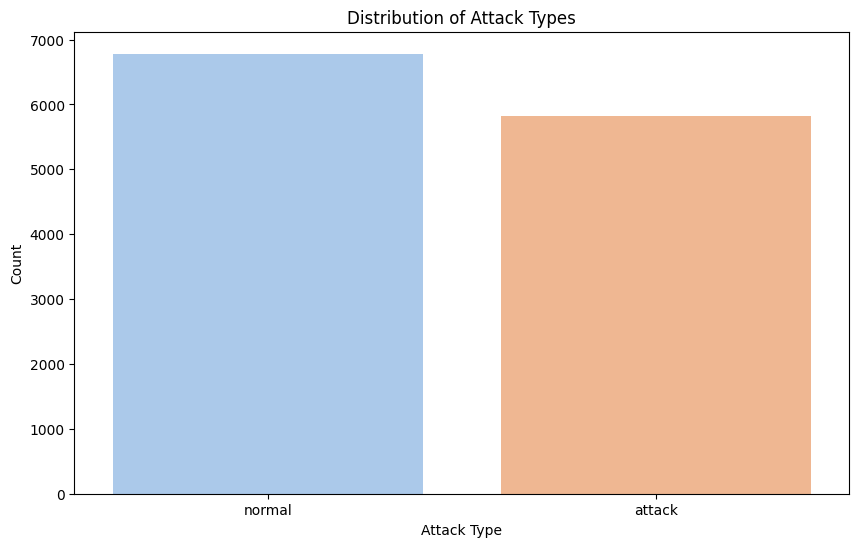

In [41]:
# Create the countplot
plt.figure(figsize=(10, 6))  # Set the figure size for better readability
sns.countplot(x=y_pred_string, palette="pastel")  # Plot the count of each predicted class

# Add labels and title
plt.xlabel("Attack Type")        # Label for the x-axis
plt.ylabel("Count")              # Label for the y-axis
plt.title("Distribution of Attack Types")  # Title of the plot

# Show the plot
plt.show()  # Display the plot